# Speed Dating Project

## Objectif

Dans ce notebook, je reponds aux consignes du projet avec une analyse simple :

- exploration des donnees,
- statistiques descriptives,
- visualisations,
- interpretations courtes.

L'idee est de comprendre **ce qui favorise un match** pendant un speed dating.


## 1. Import des librairies et chargement du dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("Speed_Dating_Data.csv", encoding="latin1")
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


## 2. Decouverte du dataset

In [2]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
print()
df.info()

Nombre de lignes : 8378
Nombre de colonnes : 195

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), str(8)
memory usage: 12.5 MB


In [3]:
missing = (df.isna().mean() * 100).sort_values(ascending=False).head(15)
missing

num_in_3    92.026737
numdat_3    82.143710
expnum      78.515159
sinc7_2     76.665075
amb7_2      76.665075
shar7_2     76.438291
attr7_2     76.318931
intel7_2    76.318931
fun7_2      76.318931
amb5_3      75.936978
attr7_3     75.936978
sinc7_3     75.936978
intel7_3    75.936978
fun7_3      75.936978
amb7_3      75.936978
dtype: float64

### Interpretation

Le dataset contient beaucoup de variables et plusieurs colonnes ont beaucoup de valeurs manquantes. Pour rester simple, je vais me concentrer sur les variables qui aident le plus a comprendre les decisions et les matches.


## 3. Comprendre la variable cible : `match`

In [4]:
match_rate = df["match"].mean() * 100
dec_rate = df["dec"].mean() * 100
dec_o_rate = df["dec_o"].mean() * 100

print(f"Taux de match : {match_rate:.2f}%")
print(f"Taux de oui de la personne observee : {dec_rate:.2f}%")
print(f"Taux de oui du partenaire : {dec_o_rate:.2f}%")

Taux de match : 16.47%
Taux de oui de la personne observee : 41.99%
Taux de oui du partenaire : 41.96%


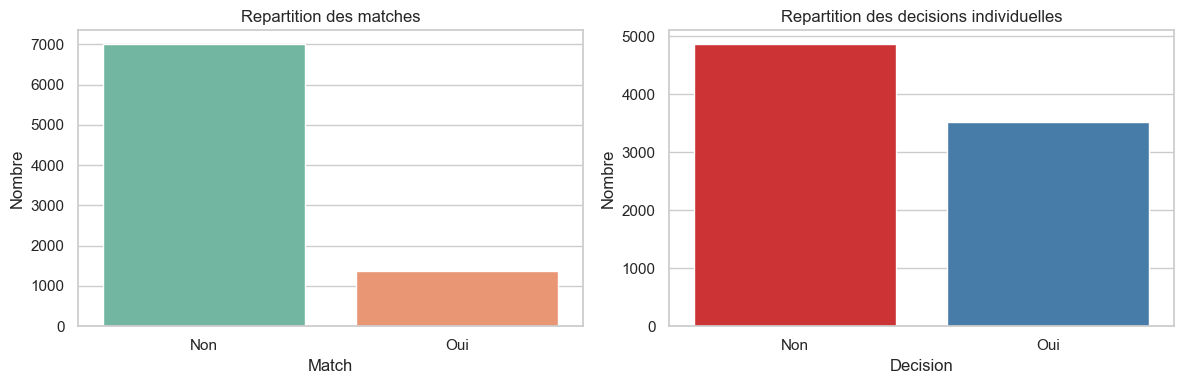

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="match", hue="match", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Repartition des matches")
axes[0].set_xlabel("Match")
axes[0].set_ylabel("Nombre")
axes[0].set_xticks([0, 1], ["Non", "Oui"])

sns.countplot(data=df, x="dec", hue="dec", palette="Set1", legend=False, ax=axes[1])
axes[1].set_title("Repartition des decisions individuelles")
axes[1].set_xlabel("Decision")
axes[1].set_ylabel("Nombre")
axes[1].set_xticks([0, 1], ["Non", "Oui"])

plt.tight_layout()
plt.show()

### Interpretation

Le match est rare, autour de 16%. C'est logique car un match demande un accord mutuel. En comparaison, dire "oui" individuellement est plus frequent.


## 4. Que recherchent les participants ?

In [6]:
df["gender_label"] = df["gender"].map({0: "Femme", 1: "Homme"})

preference_cols = ["attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1"]
preferences = (
    df.groupby("gender_label")[preference_cols]
    .mean()
    .round(2)
    .T
    .rename(columns={"Femme": "Femmes", "Homme": "Hommes"})
)
preferences

/var/folders/5f/80v9jyrj6sj__198sx_v62f40000gn/T/ipykernel_23649/2932016698.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["gender_label"] = df["gender"].map({0: "Femme", 1: "Homme"})


gender_label,Femmes,Hommes
attr1_1,18.06,26.92
sinc1_1,18.31,16.50
intel1_1,21.00,19.54
fun1_1,17.15,17.76
amb1_1,12.83,8.55
shar1_1,12.70,11.00


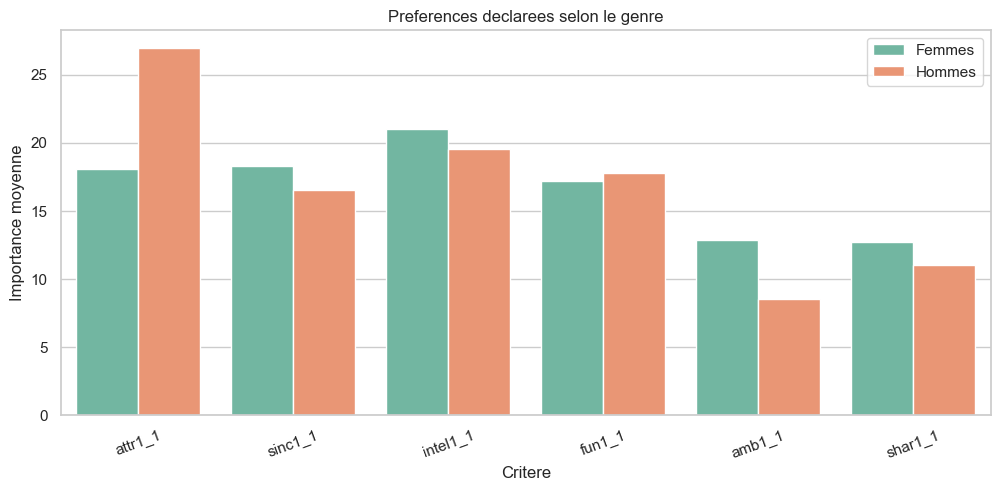

In [7]:
pref_plot = preferences.reset_index().rename(columns={"index": "critere"})
pref_plot = pref_plot.melt(id_vars="critere", var_name="groupe", value_name="importance")

plt.figure(figsize=(12, 5))
sns.barplot(data=pref_plot, x="critere", y="importance", hue="groupe", palette="Set2")
plt.title("Preferences declarees selon le genre")
plt.xlabel("Critere")
plt.ylabel("Importance moyenne")
plt.xticks(rotation=20)
plt.legend(title="")
plt.show()

### Interpretation

Les hommes declarent donner plus d'importance a l'attractivite. Les femmes declarent donner un peu plus d'importance a l'intelligence, a la sincerite et a l'ambition. Les attentes sont donc legerement differentes.


## 5. Qu'est-ce qui pousse une personne a dire oui ?

In [8]:
rating_cols = ["attr", "sinc", "intel", "fun", "amb", "shar", "like", "prob"]

decision_means = df.groupby("dec")[rating_cols].mean().round(2)
decision_means.index = ["A dit non", "A dit oui"]
decision_means

,attr,sinc,intel,fun,amb,shar,like,prob
A dit non,5.37,6.86,7.08,5.70,6.49,4.72,5.31,4.63
A dit oui,7.29,7.60,7.76,7.33,7.16,6.46,7.22,5.97


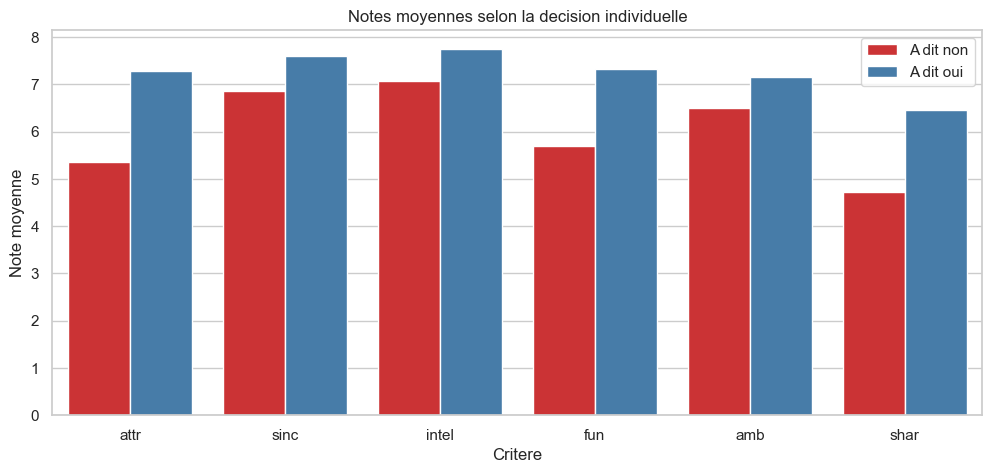

In [9]:
decision_plot = df.groupby("dec")[["attr", "sinc", "intel", "fun", "amb", "shar"]].mean().T.reset_index()
decision_plot.columns = ["critere", "A dit non", "A dit oui"]
decision_plot = decision_plot.melt(id_vars="critere", var_name="decision", value_name="score")

plt.figure(figsize=(12, 5))
sns.barplot(data=decision_plot, x="critere", y="score", hue="decision", palette="Set1")
plt.title("Notes moyennes selon la decision individuelle")
plt.xlabel("Critere")
plt.ylabel("Note moyenne")
plt.legend(title="")
plt.show()

In [10]:
corr_dec = df[rating_cols + ["dec"]].corr(numeric_only=True)["dec"].sort_values(ascending=False)
corr_dec

dec      1.000000
like     0.513463
attr     0.486775
fun      0.414477
shar     0.400644
prob     0.310861
intel    0.217313
sinc     0.209994
amb      0.183659
Name: dec, dtype: float64

### Interpretation

Quand une personne dit "oui", toutes les notes sont plus elevees. L'attractivite est tres importante, mais le fun, l'intelligence, la sincerite et les interets communs comptent aussi.


## 6. Qu'est-ce qui favorise un match ?

In [11]:
match_means = df.groupby("match")[rating_cols].mean().round(2)
match_means.index = ["Pas de match", "Match"]
match_means

,attr,sinc,intel,fun,amb,shar,like,prob
Pas de match,5.96,7.05,7.25,6.16,6.66,5.21,5.88,4.96
Match,7.32,7.81,7.95,7.60,7.33,6.75,7.38,6.41


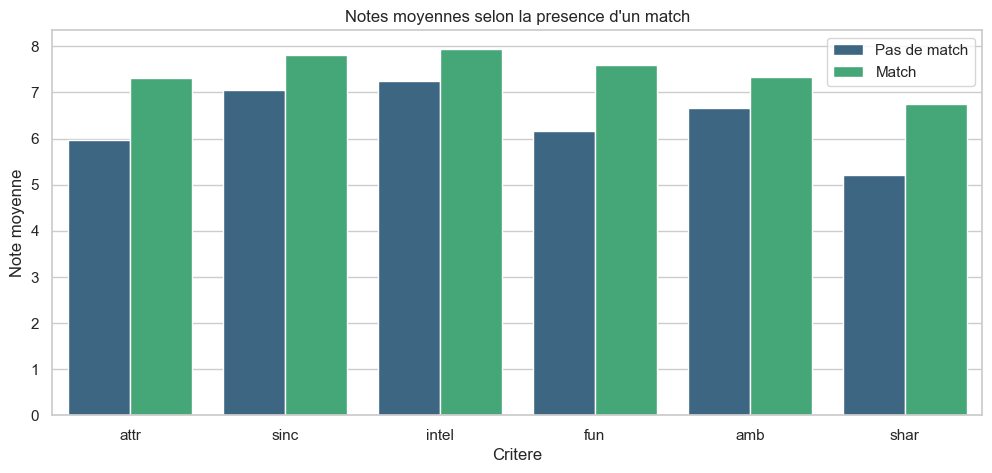

In [12]:
match_plot = df.groupby("match")[["attr", "sinc", "intel", "fun", "amb", "shar"]].mean().T.reset_index()
match_plot.columns = ["critere", "Pas de match", "Match"]
match_plot = match_plot.melt(id_vars="critere", var_name="statut", value_name="score")

plt.figure(figsize=(12, 5))
sns.barplot(data=match_plot, x="critere", y="score", hue="statut", palette="viridis")
plt.title("Notes moyennes selon la presence d'un match")
plt.xlabel("Critere")
plt.ylabel("Note moyenne")
plt.legend(title="")
plt.show()

In [13]:
corr_match = df[rating_cols + ["match"]].corr(numeric_only=True)["match"].sort_values(ascending=False)
corr_match

match    1.000000
like     0.305723
fun      0.277545
shar     0.270679
attr     0.260676
prob     0.255531
intel    0.169532
sinc     0.164449
amb      0.140042
Name: match, dtype: float64

### Interpretation

Les matches apparaissent surtout quand la rencontre est bien notee sur plusieurs dimensions a la fois. Les variables les plus liees au match sont l'appreciation globale (`like`), l'attractivite (`attr`), le fun et les interets communs (`shar`).


## 7. Deux facteurs simples a tester

In [14]:
analysis_df = df.copy()
analysis_df["age_gap"] = (analysis_df["age"] - analysis_df["age_o"]).abs()

print("Ecart d'age moyen selon le match :")
print(analysis_df.groupby("match")["age_gap"].mean().round(2))
print()
print("Taux de match selon samerace :")
print(analysis_df.groupby("samerace")["match"].mean().round(3))

Ecart d'age moyen selon le match :
match
0    3.75
1    3.18
Name: age_gap, dtype: float64

Taux de match selon samerace :
samerace
0    0.161
1    0.171
Name: match, dtype: float64


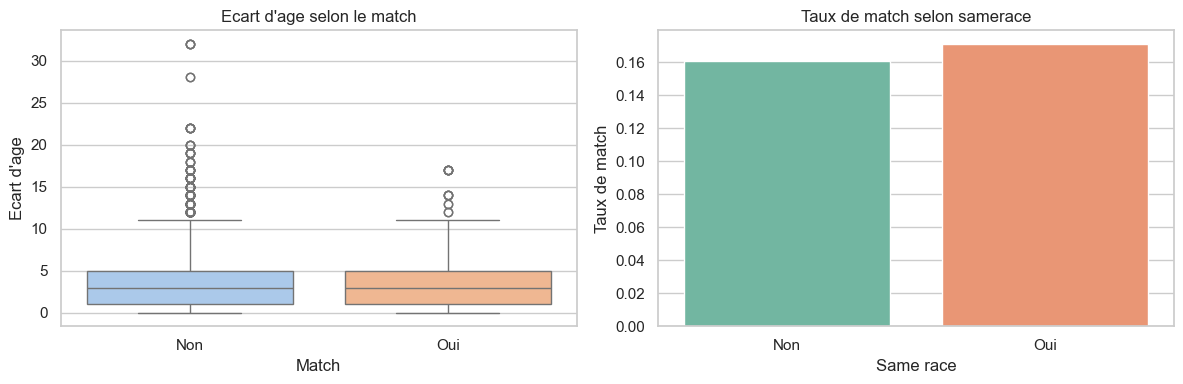

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=analysis_df, x="match", y="age_gap", hue="match", palette="pastel", legend=False, ax=axes[0])
axes[0].set_title("Ecart d'age selon le match")
axes[0].set_xlabel("Match")
axes[0].set_ylabel("Ecart d'age")
axes[0].set_xticks([0, 1], ["Non", "Oui"])

same_race = analysis_df.groupby("samerace", dropna=True)["match"].mean().reset_index()
sns.barplot(data=same_race, x="samerace", y="match", hue="samerace", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Taux de match selon samerace")
axes[1].set_xlabel("Same race")
axes[1].set_ylabel("Taux de match")
axes[1].set_xticks([0, 1], ["Non", "Oui"])

plt.tight_layout()
plt.show()

### Interpretation

Un ecart d'age plus faible semble legerement aider. Etre de la meme race semble aussi augmenter un peu le taux de match. Mais ces effets restent plus faibles que les notes donnees pendant l'interaction.


## 8. Conclusion finale

Les idees les plus importantes sont :

1. Le taux de match est faible car il faut deux reponses positives.
2. Les preferences declarees changent un peu selon le genre.
3. L'attractivite joue un role fort dans la decision individuelle.
4. Le match depend surtout d'une bonne impression globale : attractivite, fun, appreciation generale et interets communs.
5. Les variables comme l'age ou `samerace` ont un effet plus faible.

En resume, ce qui fait naitre un match n'est pas uniquement le physique. L'alchimie generale du rendez-vous semble tres importante.
